# **7.6 残差连接网络(ResNet)**

## 7.6.1 数学原理

神经网络本质上是一个通过优化迭代，求解从数据到答案的映射$f$的过程。假设我们要拟合的真实最优映射为 $f^*$，它存在于某个理想的假设空间 $\mathcal{F}^*$ 中。我们训练神经网络，实际上是在网络结构所定义的函数类（假设空间）$\mathcal{F}$ 中寻找一个距离 $f^*$ 最近的解 $f^*_{\mathcal{F}}$。即求解：
$$
f^*_\mathcal{F} := \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \text{ subject to } f \in \mathcal{F}.
$$

### 7.6.1.1. 非嵌套函数类（传统深度网络，如标准 MLP/CNN）
设 $\mathcal{F}_1$ 为浅层网络的函数类，当我们为其增加一层映射 $g(\cdot)$ 时，得到深层网络的函数类 $\mathcal{F}_2$。传统前向传播可以表示为复合函数：
$$
f_{l+1}(\mathbf{x}) = g(f_l(\mathbf{x}); W)
$$
在数学上，由于非线性激活函数和权重矩阵的乘积，新的函数类 $\mathcal{F}_2$ 并不一定包含 $\mathcal{F}_1$。即 $\mathcal{F}_1 \not\subset \mathcal{F}_2$。这导致了一个极其严重的问题：当我们增加网络深度时，虽然函数空间的“容量”变大了，但新的空间可能在几何上偏离了真实解 $f^*$。也就是说，$\mathcal{F}_2$ 中距离 $f^*$ 最近的函数，可能比 $\mathcal{F}_1$ 中距离 $f^*$ 最近的函数还要远。这就是为什么传统网络层数增加时，训练误差反而会升高的数学本质（退化问题）。
### 7.6.1.2. 嵌套函数类（ResNet 的残差连接）
ResNet 通过引入恒等映射（Identity Mapping），改变了函数类的构造方式。残差块的输出被定义为：
$$
f_{l+1}(\mathbf{x}) = f_l(\mathbf{x}) + \mathcal{F}(f_l(\mathbf{x}); W)
$$
其中 $\mathcal{F}$ 是包含权重的残差映射。此时我们考察新的函数类 $\mathcal{F}_2$ 。因为权重矩阵 $W$ 可以被优化为零矩阵（即  $\mathcal{F}(\cdot; 0) = \mathbf{0}$ ），所以：
$$
f_{l+1}(\mathbf{x}) = f_l(\mathbf{x}) + \mathbf{0} = f_l(\mathbf{x})
$$
这在数学上给出了一个极强的保证：较深网络的函数空间严格包含了较浅网络的函数空间，即：
$$
\mathcal{F}_1 \subset \mathcal{F}_2 \subset \dots \subset \mathcal{F}_L$$
在这种嵌套结构下，如果当前层数已经达到了最优的拟合状态，后续添加的层只需要将权重收敛到 $0$，网络就会退化为恒等映射。因此，增加层数在理论上绝对不会增加训练误差。

图片示意：


![alt text](https://zh-v2.d2l.ai/_images/functionclasses.svg)

### 7.6.1.3 到ResNet

综合上述内容，我们希望，在每一层，上层函数的输出作为输入所表示的空间 $\mathcal{F}_l$ 能够被包含在下一层的输出所表示的空间 $\mathcal{F}_{l+1}$ 当中。即 $\mathcal{F}_l \subset \mathcal{F}_{l+1}$。

再令上一层的输出为x，在之前所学的网络结构中，该层的输出为非线性变换 $H(x) = \sigma(Wx + b)$ ，这意味着我们需要在由权重 $W$ 和偏置 $b$ 构成的参数空间中，寻找一个极度特殊的解：使得经过激活函数 $\sigma$ 后，整个矩阵运算恰好等价于一个恒等算子（Identity Operator）。在非线性函数空间中，这几乎是不可能自然成立的，因此 $\mathcal{F}_l \not\subset \mathcal{F}_{l+1}$。而根据在嵌套函数类中所讨论的式子，我们希望输出为：
$$
y = x + F(x; W, b)
$$
从而使 $\mathcal{F}_l \subset \mathcal{F}_{l+1}$。这便是ResNet的诞生。

*在线性代数和参数优化中，让一个权重矩阵 $W$ 衰减为零矩阵 $\mathbf{0}$，比让它去拟合一个高维恒等矩阵 $I$ 及其非线性逆运算要容易得多*



## 7.6.2 残差块

由上述讨论可知，我们只需要学习残差映射 $f(\mathbf{x}) - \mathbf{x}$ 即可。那么就应该让 $f(\mathbf{x}) - \mathbf{x}$ 去走先前 $f(\mathbf{x})$ 所走的流程，最后把 $\mathbf{x}$ 给加回来即可。如图：

![alt text](https://zh-v2.d2l.ai/_images/residual-block.svg)

ResNet沿用了VGG块的设计。即两个相同输出通道数的 $3 \times 3$ 卷积层 + 批量规范化 + ReLU，并把原输出 $\mathbf{x}$ 加在激活函数前。但这要求输出通道数与输入通道数一致，于是当需要改变输出通道数时我们对 $\mathbf{x}$ 使用 $1 \times 1$ 卷积层+广播机制解决。

代码实现：

In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


class Residual(nn.Module):  #@save
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1, stride=1)
        # 1x1卷积层的作用是在需要调整输出通道数时使用。
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None

        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

In [5]:
blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

In [7]:
# 当输入和输出通道数不一致时，使用1x1卷积调整输入的通道数
blk = Residual(3,6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

## 7.6.3 ResNet模型

可视为将GoogLeNet的Inception块更换为Residual残差块并应用批量规范化。下图为ResNet-18：

![alt text](https://zh-v2.d2l.ai/_images/resnet18.svg)

老样子看看长什么样：

In [8]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


loss 0.008, train acc 0.998, test acc 0.921
2902.8 examples/sec on cuda:0


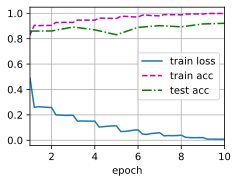

In [9]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 7.6.4 小结

- 残差块能够使得传播“更快”：
    1. 梯度的雅可比矩阵：乘法变加法（破除梯度消失）普通网络 (Plain): 雅可比矩阵为连乘。
    $$
    \frac{\partial x_L}{\partial x_l} = \prod_{i=l}^{L-1} W_i 
    $$
    *(多矩阵连乘 $\rightarrow$ 特征值呈指数衰减/爆炸 $\rightarrow$ 梯度消失)*

    2. 残差网络 (ResNet): 雅可比矩阵为相加。
    $$ \frac{\partial x_L}{\partial x_l} = I + \sum_{i=l}^{L-1} \frac{\partial \mathcal{F}(x_i, \mathcal{W}_i)}{\partial x_i} 
    $$
    *(单位阵 $I$ 充当恒等映射，保证梯度 $\frac{\partial \mathcal{L}}{\partial x_L}$ 跨层无损加法回传)*

**疑问**：
1. GoogLeNet 的并列分支（如 1×1 卷积）设计，是否说明其内部已经蕴含了 ResNet 的残差思想？
2. ResNet 后续版本（ResNet-v2）将残差块结构从“Conv-BN-ReLU”改为“BN-ReLU-Conv”（预激活，把最后的ReLU给提前了）的核心意义是什么？

**Ans**：
1. **未蕴含。** GoogLeNet 是**非线性变换**（带权重和激活的 1×1 卷积）提取特征并进行**通道拼接（Concat）**；ResNet 是**恒等映射**（无权重的原值传递）与主干特征**逐元素相加（Add）**。
2. **能够更好保留原函数，更加符合最初思路**。将 ReLU 前置，消除了其对旁路信息相加后的非负截断，实现了真正无损的“恒等映射”，使梯度能在极深网络中畅通无阻；同时，BN 层前置对输入卷积的信号进行了强制归一化，有效增强了深层网络的抗过拟合能力。
    - 原版：$x_{l+1} = \text{ReLU}(x_l + \mathcal{F}(x_l))$
    - 改进：$x_{l+1} = x_l + \mathcal{F}(\text{ReLU}(\text{BN}(x_l)))$

## 7.6.5 补充：Bottleneck

“瓶颈”结构如其名，有“两头宽、中间窄”的特点。将原本的两个 $3 \times 3$ 卷积结构改为 $1 \times 1$ 降维 + $3 \times 3$ 提取特征+ $1 \times 1$ 升维的结构。这样能够大幅的降低“计算奢侈”的卷积层的参数量和计算量。使得网络能够更深。

以一个输入输出通道均为x的特征图为例：
- 普通残差块 (Basic Block)
    
    参数量 = $(3 \times 3 \times x \times x) \times 2 \approx \mathbf{18x^2}$ 个参数 
- 瓶颈块 (Bottleneck Block)
    
    使用 $1 \times 1$ (降到 x/4) $\rightarrow$ $3 \times 3$ (保持 x/4) $\rightarrow$ $1 \times 1$ (升回 x)。
    
    - 第一层：$1 \times 1 \times x \times x/4 = x^2/4$
    - 第二层：$3 \times 3 \times x/4 \times x/4 = 9x^2/16$
    - 第三层：$1 \times 1 \times x/4 \times x = x^2/4$参数量 = $x^2/4 + 9x^2/16 + x^2/4 = \mathbf{17x^2/16}$ 个参数

仅原计算量的17分之一。


代码实现（包含其他变体）：

In [3]:
class BasicBlock(nn.Module):
    expansion = 1 #普通resnet block

    def __init__(self, in_channels, out_channels, stride=1, downsample=None): #downsample是判断是否需要调整旁路尺寸
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x #旁路

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out
    
class BottleneckBlock(nn.Module):
    expansion = 4 #瓶颈结构

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BottleneckBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True) #inplace指定是否进行原地操作，节省内存
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x #旁路

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

多种变体实现：

In [ ]:
def make_layer(block, in_channels, out_channels, blocks, stride=1): #blocks是指该层包含多少个残差块
    downsample = None
    if stride != 1 or in_channels != out_channels * block.expansion: #当需要调整尺寸（步幅！=1 以及输入通道数不匹配）时，使用1x1卷积调整输入的通道数和空间尺寸
        downsample = nn.Sequential(
            nn.Conv2d(in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels * block.expansion)
        )

    layers = []
    layers.append(block(in_channels, out_channels, stride, downsample))
    in_channels = out_channels * block.expansion #只有第一个残差块可能需要调整尺寸，后续的残差块输入输出通道数都对应，无需调整旁路
    for _ in range(1, blocks):
        layers.append(block(in_channels, out_channels))

    return nn.Sequential(*layers)

def resnet(arch):
    block, layers = { 
        'resnet18': (BasicBlock, [2, 2, 2, 2]),
        'resnet34': (BasicBlock, [3, 4, 6, 3]),
        'resnet50': (BottleneckBlock, [3, 4, 6, 3]),
    }[arch]
    #这个字典的作用是根据输入的arch参数选择对应的block类型和每层的残差块数量；
    #layers与上面make_layer的layers并无直接关系，而是定义了每层的残差块数量，供后续调用make_layer时使用

    b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                       nn.BatchNorm2d(64), nn.ReLU(),
                       nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

    b2 = make_layer(block, 64, 64, layers[0])
    b3 = make_layer(block, 64 * block.expansion, 128, layers[1], stride=2)
    b4 = make_layer(block, 128 * block.expansion, 256, layers[2], stride=2)
    b5 = make_layer(block, 256 * block.expansion, 512, layers[3], stride=2)

    net = nn.Sequential(b1, b2, b3, b4, b5,
                        nn.AdaptiveAvgPool2d((1, 1)),
                        nn.Flatten(), nn.Linear(512 * block.expansion, 10))

    return net

net = resnet('resnet50')
    
net

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): BottleneckBlock(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), 